## **Instituto Tecnológico y de Estudios Superiores de Monterrey**

### Development of advanced applications for computer science

### Final project: Plagarism detector

Diego Reséndiz Fernández A01708017

Jesús Ramírez Delgado A01274723

Félix Javier Rojas Gallardo A01201946



# Abstract



# Introduction



# Data acquisition

We use a small dataset by ehsankhani for python plagiarised code and original code. This dataset is particularly useful as a base for testing.

Run the cells below to acquire dataset.


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


!pip install asttokens

In [ ]:
user = "ehsankhani"
repo = "cheating_detector"
src_dir = "DataSet"

csv_plagiarism = "cheating_dataset.csv"
csv_plagiarism_features = "cheating_features_dataset.csv"
branch = "refs/heads/master"

base_url = f"https://raw.githubusercontent.com/{user}/{repo}/{branch}/{src_dir}"

for files in [csv_plagiarism, csv_plagiarism_features]:
  url = f"{base_url}/{files}"
  !wget --no-cache --backups=1 {url}

--2026-04-27 22:50:07--  https://raw.githubusercontent.com/ehsankhani/cheating_detector/refs/heads/master/DataSet/cheating_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10218 (10.0K) [text/plain]
Failed to rename cheating_dataset.csv to cheating_dataset.csv.1: (2) No such file or directory
Saving to: ‘cheating_dataset.csv’

cheating_dataset.cs 100%[===================>]   9.98K  --.-KB/s    in 0s      

2026-04-27 22:50:07 (74.5 MB/s) - ‘cheating_dataset.csv’ saved [10218/10218]

--2026-04-27 22:50:07--  https://raw.githubusercontent.com/ehsankhani/cheating_detector/refs/heads/master/DataSet/cheating_features_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Con

In [ ]:

print("#------------------------------------Instancias----------------------------------------")
df_plagiarism = pd.read_csv(csv_plagiarism)
print("#---------------------Dataset de las instancias-----------------")
print("#---------------------Cual es la distribución de casos en dónde es plagio y de dónde no?-----------------")
print(df_plagiarism.Label.value_counts())
print("#---------------------Falta algún valor?-----------------")
print(df_plagiarism.isnull().sum())
print("#---------------------Columnas-----------------")
print(df_plagiarism.columns)

#------------------------------------Instancias----------------------------------------
#---------------------Dataset de las instancias-----------------
#---------------------Cual es la distribución de casos en dónde es plagio y de dónde no?-----------------
Label
0    193
1    100
Name: count, dtype: int64
#---------------------Falta algún valor?-----------------
File_1    0
File_2    0
Label     0
dtype: int64
#---------------------Columnas-----------------
Index(['File_1', 'File_2', 'Label'], dtype='object')


In [ ]:
print("#------------------------------------features----------------------------------------")
df_features = pd.read_csv(csv_plagiarism_features)
print("#---------------------Dataset de las features-----------------")
print("#---------------------Cual es la distribución de casos en dónde es plagio y de dónde no?-----------------")
print(df_plagiarism.Label.value_counts())
print("#---------------------Falta algún valor?-----------------")
print(df_plagiarism.isnull().sum())
print("#---------------------Columnas-----------------")
print(df_plagiarism.columns)

#------------------------------------features----------------------------------------
#---------------------Dataset de las features-----------------
#---------------------Cual es la distribución de casos en dónde es plagio y de dónde no?-----------------
Label
0    193
1    100
Name: count, dtype: int64
#---------------------Falta algún valor?-----------------
File_1    0
File_2    0
Label     0
dtype: int64
#---------------------Columnas-----------------
Index(['File_1', 'File_2', 'Label'], dtype='object')


In [ ]:
print("#--------------------Correlacion features con el resultado---------------------------")
correlacion = df_features.corr()['Label'].sort_values(ascending=False)
print("#--- Influencia de las Features ---")
print(correlacion)

#--------------------Correlacion features con el resultado---------------------------
#--- Influencia de las Features ---
Label                           1.000000
Token Similarity                0.602586
Levenshtein Similarity          0.336851
Comment Ratio File 2            0.235307
Comment Ratio File 1            0.222671
AST Similarity                  0.154237
Variable Count File 2           0.102334
Variable Count File 1           0.093459
Function Count File 2          -0.032320
Function Count File 1          -0.075804
Length File 1                  -0.083170
Length File 2                  -0.109015
Cyclomatic Complexity File 1   -0.129233
Cyclomatic Complexity File 2   -0.191628
Name: Label, dtype: float64


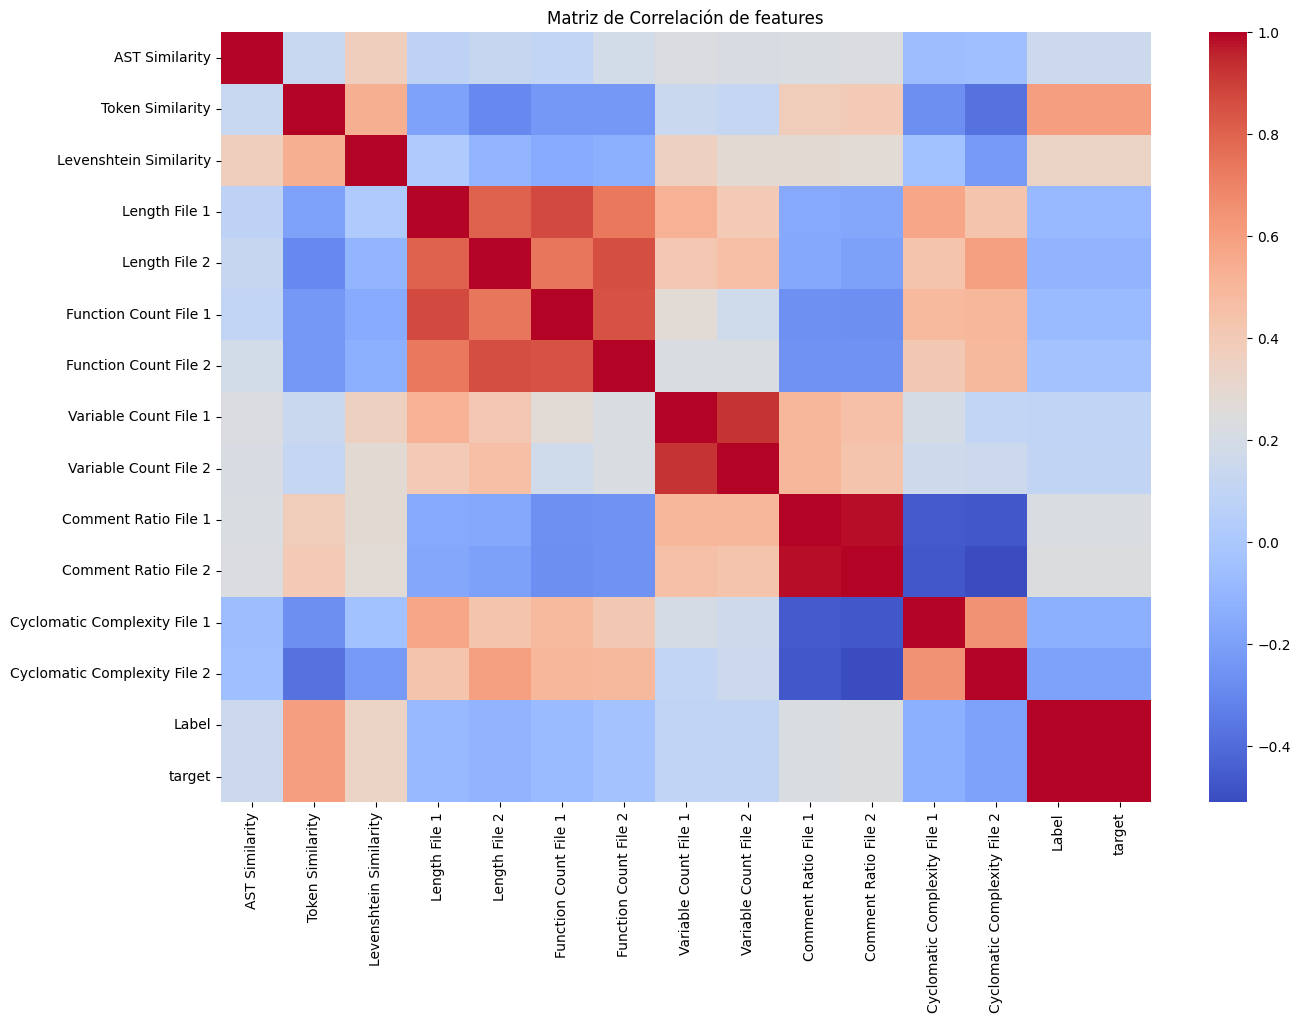

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_features.assign(target=df_plagiarism.Label).corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de Correlación de features')
plt.show()

In [ ]:
plagiarized_codes = df_plagiarism.where(df_plagiarism['Label'] == 1).dropna()
plagiarized_codes

,File_1,File_2,Label
0,submission1.py,submission2.py,1.0
2,submission1.py,submission4.py,1.0
5,submission2.py,submission4.py,1.0
10,submission6.py,submission7.py,1.0
11,submission8.py,submission9.py,1.0
...,...,...,...
288,submission171.py,submission173.py,1.0
289,submission171.py,submission174.py,1.0
290,submission172.py,submission173.py,1.0
291,submission172.py,submission174.py,1.0


In [ ]:
non_plagiarized_codes = df_plagiarism.where(df_plagiarism['Label'] == 0).dropna()
non_plagiarized_codes

,File_1,File_2,Label
1,submission1.py,submission3.py,0.0
3,submission1.py,submission5.py,0.0
4,submission2.py,submission3.py,0.0
6,submission2.py,submission5.py,0.0
7,submission3.py,submission4.py,0.0
...,...,...,...
252,submission144.py,submission145.py,0.0
253,submission142.py,submission146.py,0.0
254,submission143.py,submission146.py,0.0
255,submission144.py,submission146.py,0.0


In [ ]:
non_plagiarized_codes.groupby('File_1').nunique()

NameError: name 'non_plagiarized_codes' is not defined

In [ ]:
code_to_plagiarize = non_plagiarized_codes.groupby('File_1').nunique().drop(['Label', 'File_2'], axis=1).reset_index()
code_to_plagiarize

NameError: name 'non_plagiarized_codes' is not defined

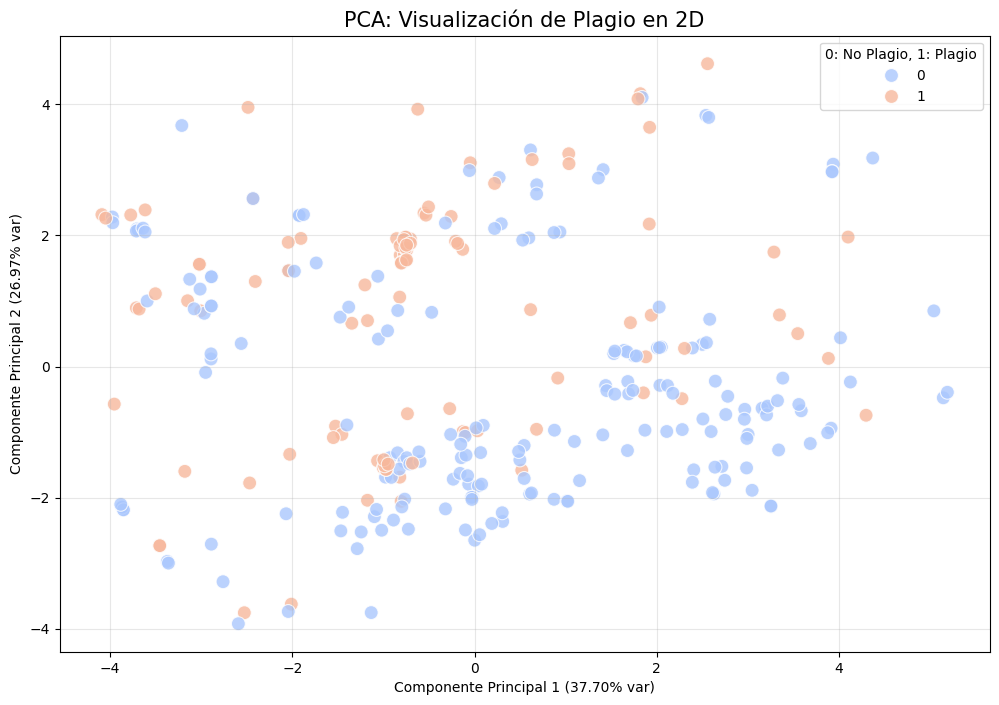

--- Features que más influyen en el Componente 1 ---
Length File 2                   0.393602
Function Count File 1           0.389010
Length File 1                   0.384847
Function Count File 2           0.381036
Cyclomatic Complexity File 2    0.343654
Name: PC1, dtype: float64

--- Features que más influyen en el Componente 2 ---
Variable Count File 1     0.461758
Variable Count File 2     0.443219
Comment Ratio File 1      0.413782
Comment Ratio File 2      0.399457
Levenshtein Similarity    0.284083
Name: PC2, dtype: float64


In [ ]:
X = df_features.drop('Label', axis=1)
y = df_features['Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=componentes_principales, columns=['PC1', 'PC2'])
df_pca['Resultado'] = y.values


plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Resultado', data=df_pca,
                palette='coolwarm', s=100, alpha=0.8)

plt.title('PCA: Visualización de Plagio en 2D', fontsize=15)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%} var)')
plt.legend(title='0: No Plagio, 1: Plagio')
plt.grid(alpha=0.3)
plt.show()

# Ver cuánto peso tiene cada característica original en los componentes
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns)

# Esto te dice qué features "empujan" más el eje PC1 (el más importante)
print("--- Features que más influyen en el Componente 1 ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))

print("\n--- Features que más influyen en el Componente 2 ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))


In [ ]:
folder_name = "PythonDataSet"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

unique_values = pd.unique(df_plagiarism[['File_1', 'File_2']].values.ravel('K'))

for value in unique_values:
    url = f"{base_url}/{value}"
    !wget --no-cache --backups=1 -P {folder_name} {url}

--2026-04-27 22:50:08--  https://raw.githubusercontent.com/ehsankhani/cheating_detector/refs/heads/master/DataSet/submission1.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32 [text/plain]
Failed to rename PythonDataSet/submission1.py to PythonDataSet/submission1.py.1: (2) No such file or directory
Saving to: ‘PythonDataSet/submission1.py’

submission1.py      100%[===================>]      32  --.-KB/s    in 0s      

2026-04-27 22:50:08 (2.25 MB/s) - ‘PythonDataSet/submission1.py’ saved [32/32]

--2026-04-27 22:50:08--  https://raw.githubusercontent.com/ehsankhani/cheating_detector/refs/heads/master/DataSet/submission2.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connectin

# Data processing

## Code generation from Gemini API

In [ ]:
5

In [ ]:
from google import genai
from google.genai import types
from google.colab import userdata

client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

def generate_obfuscated_code(original_code):
  prompt = f"""
    Rewrite the following Python code so that it is obfuscated but produces the same output.
    Only return the obfuscated code, with no explanations or comments.
    Do not use any formatting.

    Original code:
    {original_code}
    """
  response = client.models.generate_content(
      model="gemini-2.5-flash-lite",
      contents=prompt)
  return response.text

generate_obfuscated_code("print('Hello World')")

SecretNotFoundError: Secret GEMINI_API_KEY does not exist.

In [ ]:
exec('pr'+'in'+'t(\'He'+'llo Wor'+'ld\')')

In [ ]:
def generate_plagiarized_code(original_code):
  prompt = f"""
    Reorder the code execution, modify variable names, function names, but keep the logic identical.
    Only return the modified code, with no explanations or comments.
    Do not use any formatting.

    Original code:
    {original_code}
    """
  response = client.models.generate_content(
      model="gemini-2.5-flash-lite",
      contents=prompt)
  return response.text

string_to_exec = generate_plagiarized_code("print('Hello World')")

In [ ]:
string_to_exec

In [ ]:
exec(string_to_exec)

## AST generation

In [ ]:
import ast
import pickle

ast_output_dir = './AST/human'
if not os.path.exists(ast_output_dir):
    os.makedirs(ast_output_dir)

# generate AST trees from files
for root, dirs, files in os.walk('./PythonDataSet'):
  if 'AST' in dirs:
    dirs.remove('AST')
  # print(f"Current Directory: {root}")
  for file in files:
    if file.endswith('.py'):
        full_path = os.path.join(root, file)
        try:
          with open(full_path, 'r', encoding='utf-8') as f:
              content = f.read()
              tree = ast.parse(content)
          pickle_name = f"{file}.pkl"
          with open(os.path.join(ast_output_dir, pickle_name), "wb") as pf:
            pickle.dump(tree, pf)
          # print(f"  File: {full_path}")
        except Exception as e:
          print(f"  Error processing file: {full_path}")

ast_output_dir_gemini = './AST/gemini'
if not os.path.exists(ast_output_dir_gemini):
    os.makedirs(ast_output_dir_gemini)

for root, dirs, files in os.walk('./ai_modified_code/gemini'):
  if 'AST' in dirs:
    dirs.remove('AST')
  # print(f"Current Directory: {root}")
  for file in files:
    if file.endswith('.py'):
        full_path = os.path.join(root, file)
        try:
          with open(full_path, 'r', encoding='utf-8') as f:
              content = f.read()
              tree = ast.parse(content)
          pickle_name = f"{file}.pkl"
          with open(os.path.join(ast_output_dir_gemini, pickle_name), "wb") as pf:
            pickle.dump(tree, pf)
          # print(f"  File: {full_path}")
        except Exception as e:
          print(f"  Error processing file: {full_path}")

ast_output_dir_mistral = './AST/mistral'
if not os.path.exists(ast_output_dir_mistral):
    os.makedirs(ast_output_dir_mistral)

for root, dirs, files in os.walk('./ai_modified_code/mistral'):
  if 'AST' in dirs:
    dirs.remove('AST')
  # print(f"Current Directory: {root}")
  for file in files:
    if file.endswith('.py'):
        full_path = os.path.join(root, file)
        try:
          with open(full_path, 'r', encoding='utf-8') as f:
              content = f.read()
              tree = ast.parse(content)
          pickle_name = f"{file}.pkl"
          with open(os.path.join(ast_output_dir_mistral, pickle_name), "wb") as pf:
            pickle.dump(tree, pf)
          # print(f"  File: {full_path}")
        except Exception as e:
          print(f"  Error processing file: {full_path}")


ast_output_dir_deepseek = './AST/deepseek'
if not os.path.exists(ast_output_dir_deepseek):
    os.makedirs(ast_output_dir_deepseek)

for root, dirs, files in os.walk('./ai_modified_code/deepseek'):
  if 'AST' in dirs:
    dirs.remove('AST')
  # print(f"Current Directory: {root}")
  for file in files:
    if file.endswith('.py'):
        full_path = os.path.join(root, file)
        try:
          with open(full_path, 'r', encoding='utf-8') as f:
              content = f.read()
              tree = ast.parse(content)
          pickle_name = f"{file}.pkl"
          with open(os.path.join(ast_output_dir_deepseek, pickle_name), "wb") as pf:
            pickle.dump(tree, pf)
          # print(f"  File: {full_path}")
        except Exception as e:
          print(f"  Error processing file: {full_path}")

## General comparison of AST

In [ ]:
with open("/content/AST/submission107.py.pkl", "rb") as tree_file:
            ast_tree_file = pickle.load(tree_file)
            print(ast.dump(ast_tree_file, indent=4))

In [ ]:
with open("/content/AST/submission109.py.pkl", "rb") as tree_file:
            ast_tree_file = pickle.load(tree_file)
            print(ast.dump(ast_tree_file, indent=4))

## AST tokenization

In [ ]:
import asttokens

ast_tree_file = None

source_code_path = "/content/PythonDataSet/submission109.py"

with open(source_code_path, "r", encoding="utf-8") as source_file:
    source_code = source_file.read()

atok = asttokens.ASTTokens(source_code, parse=True)

comments = [token.string for token in atok.tokens if token.type == 64]

comments

# for token in atok.tokens:
#     print(f"{token.start[0]:3}:{token.start[1]:3} {token.type:15} '{token.string}'")

# for token in atok.tokens:
    # print(f"Type: {token.type}, String: {token.string}, Start: {token.start}, End: {token.end}")

In [ ]:
import os
import time
from google import genai
from google.genai import types
from google.colab import userdata

client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

def generate_plagiarized_code(filenames, output_directory="ai_modified_code"):
    """
    Reads a list of files, generates modified code via API, and saves results.
    Handles resume logic by skipping already existing output files.
    """
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    for filename in filenames:
        # Define the output path to check for existing progress
        output_filename = f"mod_{os.path.basename(filename)}"
        output_path = os.path.join(output_directory, output_filename)

        # Resume logic: Skip if the file was already successfully generated
        if os.path.exists(output_path):
            continue

        try:
            with open(filename, 'r') as f:
                original_code = f.read()

            prompt = f"""
            Reorder the code execution, modify variable names, function names, but keep the logic identical.
            Only return the modified code, with no explanations or comments.
            Do not use any formatting (no markdown backticks).

            Original code:
            {original_code}
            """

            response = client.models.generate_content(
                model="gemini-2.5-flash-lite",
                contents=prompt
            )

            # Check if response is valid and contains text
            if hasattr(response, 'text') and response.text:
                cleaned_code = response.text.strip()

                # Save the generated code
                with open(output_path, 'w') as out_f:
                    out_f.write(cleaned_code)
            else:
                print(f"Warning: Empty response for {filename}. Skipping.")

        except Exception as e:
            # Handle API errors, network timeouts, or file read errors
            print(f"Error processing {filename}: {e}")
            # Optional: Sleep to prevent rapid-fire failures during network instability
            time.sleep(2)
            continue


SecretNotFoundError: Secret GEMINI_API_KEY does not exist.

In [ ]:
code_to_plagiarize_by_generation = []
for index, row in code_to_plagiarize.iterrows():
  code_to_plagiarize_by_generation.append("/content/PythonDataSet/"+row['File_1'])

code_to_plagiarize_by_generation

['/content/PythonDataSet/submission1.py',
 '/content/PythonDataSet/submission10.py',
 '/content/PythonDataSet/submission100.py',
 '/content/PythonDataSet/submission102.py',
 '/content/PythonDataSet/submission103.py',
 '/content/PythonDataSet/submission104.py',
 '/content/PythonDataSet/submission105.py',
 '/content/PythonDataSet/submission107.py',
 '/content/PythonDataSet/submission108.py',
 '/content/PythonDataSet/submission109.py',
 '/content/PythonDataSet/submission110.py',
 '/content/PythonDataSet/submission112.py',
 '/content/PythonDataSet/submission113.py',
 '/content/PythonDataSet/submission114.py',
 '/content/PythonDataSet/submission115.py',
 '/content/PythonDataSet/submission117.py',
 '/content/PythonDataSet/submission118.py',
 '/content/PythonDataSet/submission119.py',
 '/content/PythonDataSet/submission12.py',
 '/content/PythonDataSet/submission120.py',
 '/content/PythonDataSet/submission122.py',
 '/content/PythonDataSet/submission123.py',
 '/content/PythonDataSet/submission1

In [ ]:
generate_plagiarized_code(code_to_plagiarize_by_generation)

NameError: name 'generate_plagiarized_code' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 

In [ ]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import os

def download_dataset_files():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    # Folder IDs
    gemini_plagiarism = '1y70kI-01sU8x_XuAKXO17nEDv88UNvjJ'
    og_dataset_folder_id = '1DhiyW1bry8AK7pOHq52wQXc6UuwrNBix'
    deepseek_plagiarism = '1BiI6qNF1pVvH8wBEVivBzuIwu1ZpkkUg'
    mistral_plagiarism = '1o8vWFFjbEAogeIHJbLDya_Xj7JNmjM7_'

    # Map model names to their Google Drive folder IDs
    ai_sources = {
        'gemini': gemini_plagiarism,
        'deepseek': deepseek_plagiarism,
        'mistral': mistral_plagiarism
    }

    # Original dataset file list
    og_dataset_file_list = drive.ListFile(
        {'q': f"'{og_dataset_folder_id}' in parents and trashed=false"}
    ).GetList()

    # Local directory paths
    python_dataset_folder = './PythonDataSet'
    ai_plagiarized_dataset_folder = './ai_modified_code'

    # Create base directories if they don't exist
    if not os.path.exists(python_dataset_folder):
        os.makedirs(python_dataset_folder)
    if not os.path.exists(ai_plagiarized_dataset_folder):
        os.makedirs(ai_plagiarized_dataset_folder)

    # Download original dataset files
    for file in og_dataset_file_list:
        save_path = os.path.join(python_dataset_folder, file['title'])
        file.GetContentFile(save_path)
        print(f"Downloaded original: {file['title']}")

    # Download AI-generated files, each model in its own subfolder
    for model_name, folder_id in ai_sources.items():
        # Get list of files from this AI source
        file_list = drive.ListFile(
            {'q': f"'{folder_id}' in parents and trashed=false"}
        ).GetList()

        if not file_list:
            print(f"No files found in {model_name} folder.")
            continue

        # Create subdirectory for this model
        model_folder = os.path.join(ai_plagiarized_dataset_folder, model_name)
        if not os.path.exists(model_folder):
            os.makedirs(model_folder)

        # Download each file into the model's subfolder
        for file in file_list:
            save_path = os.path.join(model_folder, file['title'])
            file.GetContentFile(save_path)
            print(f"Downloaded {model_name}: {file['title']}")

download_dataset_files()

MessageError: Error: credential propagation was unsuccessful

# **Division del dataset**


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

features_test, features_val, resultado_test, resultado_val = train_test_split(
    x_temp, y_temp, test_size=0.20, random_state=42
)

print(f"Entrenamiento: {len(x_train)} muestras")
print(f"Test (Examen final): {len(features_test)} muestras")
print(f"Validación (Durante entrenamiento): {len(features_val)} muestras")

Entrenamiento: 234 muestras
Test (Examen final): 47 muestras
Validación (Durante entrenamiento): 12 muestras


# Benchmark: Logistic Regression

As a baseline benchmark, a Logistic Regression model was choosen to be implemented using the same extracted numerical features used by the neural network models. This model provides a simple, interpretable, and lightweight reference point for evaluating whether more complex models provide a meaningful improvement.

The model was trained using the training split and evaluated on the final test split. The reported metrics include:
- Accuracy
- Precision
- Recall
- F1-score
- AUC-ROC
- Confusion Matrix.

This model do not pretend to get the best results just a point of reference to compare other models or architectures and debate if more complex models such as neural networks are justified for this project.

              BENCHMARK: LOGISTIC REGRESSION

Accuracy: 0.7660
AUC-ROC:  0.8410

---------------- Classification Report ----------------

              precision    recall  f1-score   support

   No Plagio       0.76      0.90      0.83        29
      Plagio       0.77      0.56      0.65        18

    accuracy                           0.77        47
   macro avg       0.77      0.73      0.74        47
weighted avg       0.77      0.77      0.76        47

---------------- Confusion Matrix Manual ----------------

-------------------------------------------
            label neg   label pos
pred neg    26         8         
pred pos    3          10        
-------------------------------------------


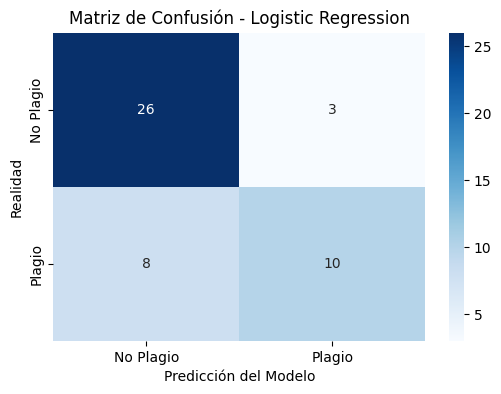

In [ ]:
# ============================================================
# Benchmark: Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Crear y entrenar el modelo
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(x_train, y_train)

# ------------------------------------------------------------
# 2. Predicciones sobre el conjunto de test
# ------------------------------------------------------------

y_pred = logistic_model.predict(features_test)

# Probabilidad de pertenecer a la clase 1: plagio
y_pred_prob = logistic_model.predict_proba(features_test)[:, 1]

# ------------------------------------------------------------
# 3. Métricas principales
# ------------------------------------------------------------

print("============================================================")
print("              BENCHMARK: LOGISTIC REGRESSION")
print("============================================================\n")

accuracy = accuracy_score(resultado_test, y_pred)
roc_auc = roc_auc_score(resultado_test, y_pred_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC:  {roc_auc:.4f}")

print("\n---------------- Classification Report ----------------\n")
print(classification_report(
    resultado_test,
    y_pred,
    target_names=["No Plagio", "Plagio"]
))

# ------------------------------------------------------------
# 4. Matriz de confusión manual
# ------------------------------------------------------------

TP = 0
TN = 0
FP = 0
FN = 0

test_labels = resultado_test.values.flatten()

for i in range(len(y_pred)):
    if y_pred[i] == 1:
        if test_labels[i] == 1:
            TP += 1
        else:
            FP += 1
    else:
        if test_labels[i] == 0:
            TN += 1
        else:
            FN += 1

print("---------------- Confusion Matrix Manual ----------------\n")
print('-------------------------------------------')
print('           ', 'label neg ', ' label pos')
print(f'pred neg    {TN:<10} {FN:<10}')
print(f'pred pos    {FP:<10} {TP:<10}')
print('-------------------------------------------')

# ------------------------------------------------------------
# 5. Matriz de confusión visual
# ------------------------------------------------------------

cm = confusion_matrix(resultado_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Plagio", "Plagio"],
    yticklabels=["No Plagio", "Plagio"]
)

plt.title("Matriz de Confusión - Logistic Regression")
plt.ylabel("Realidad")
plt.xlabel("Predicción del Modelo")
plt.show()

# **Modelo MLP**


In [ ]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(13, activation='relu', input_shape=(13,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:

history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=5,
    validation_data=(features_val, resultado_val),
    verbose=1
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4487 - loss: 0.7480 - val_accuracy: 0.6667 - val_loss: 0.6284
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7009 - loss: 0.6271 - val_accuracy: 0.7500 - val_loss: 0.5571
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7906 - loss: 0.5603 - val_accuracy: 0.6667 - val_loss: 0.5204
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8077 - loss: 0.5079 - val_accuracy: 0.6667 - val_loss: 0.5062
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8120 - loss: 0.4694 - val_accuracy: 0.7500 - val_loss: 0.4993
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8120 - loss: 0.4417 - val_accuracy: 0.7500 - val_loss: 0.5024
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8162 - loss: 0.4238 - val_accuracy: 0.7500 - val_loss: 0.5162
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8205 - loss: 0.4088 - val_accuracy: 0.7500 - val_los

In [ ]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 13)             │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,271 (4.97 KB)

 Trainable params: 423 (1.65 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 848 (3.32 KB)

None


In [ ]:

classes_x = (model.predict(features_test) > 0.5).astype(int).flatten()
test_labels = resultado_test.values.flatten()

TP = 0
TN = 0
FP = 0
FN = 0

for i in range(len(classes_x)):
  if classes_x[i] == 1:
    if test_labels[i] == 1:
      TP = TP + 1
    else :
      FP = FP + 1
  else:
    if test_labels[i] == 0:
      TN = TN + 1
    else :
      FN = FN + 1

print('-------------------------------------------')
print('           ', 'label neg ', ' label pos')
print(f'pred neg    {TN:<10} {FN:<10}')
print(f'pred pos    {FP:<10} {TP:<10}')
print('-------------------------------------------')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
-------------------------------------------
            label neg   label pos
pred neg    27         8         
pred pos    2          10        
-------------------------------------------


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
---------------- Resumen de Métricas ----------------

              precision    recall  f1-score   support

     Clase 0       0.77      0.93      0.84        29
     Clase 1       0.83      0.56      0.67        18

    accuracy                           0.79        47
   macro avg       0.80      0.74      0.76        47
weighted avg       0.80      0.79      0.78        47

AUC-ROC Score: 0.8582


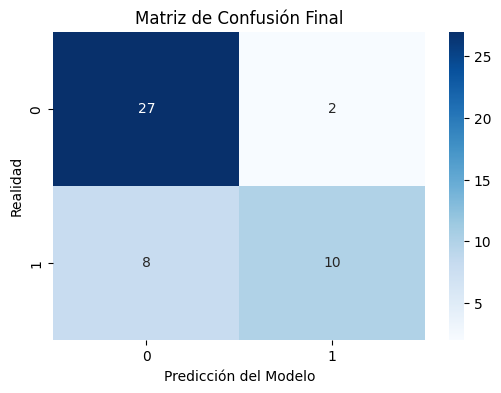

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_prob = model.predict(features_test)
y_pred = (y_pred_prob > 0.5).astype(int)


print("---------------- Resumen de Métricas ----------------\n")

print(classification_report(resultado_test, y_pred, target_names=['Clase 0', 'Clase 1']))


roc_val = roc_auc_score(resultado_test, y_pred_prob)
print(f"AUC-ROC Score: {roc_val:.4f}")


plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(resultado_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión Final')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()